## 1. Install dependencies

In [1]:
!pip install -q tiktoken datasets
try:
    import triton
    print(f'Triton already available: version {triton.__version__}')
except ImportError:
    !pip install -q triton

Triton already available: version 3.6.0


In [2]:
import os
os.makedirs('model', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)

In [3]:
%%writefile model/__init__.py


Writing model/__init__.py


In [4]:
%%writefile model/attention.py
"""
model/attention.py

Phase 4: two interchangeable causal self-attention implementations with the
exact same __init__/forward signature, so model/gpt.py's Block can swap
between them via a single flag (GPTConfig.use_fused_kernel) without changing
anything else about the model.

  - CausalSelfAttention:
        The vanilla baseline. Uses PyTorch's built-in scaled_dot_product_attention,
        which already dispatches to a fused, Flash-Attention-style kernel on
        supported GPUs (including the T4). This is a genuinely strong baseline,
        not a strawman -- which is exactly what makes beating it meaningful.
        Also the only one of the two that supports KV-caching (Phase 5, see
        the KVCache class at the bottom of this file).

  - FusedCausalSelfAttention:
        Our own hand-written fused attention kernel, implemented in Triton.
        Forward pass only: it never materializes the full (T x T) attention
        matrix in memory, using an "online softmax" the same way FlashAttention
        does. Mathematically identical output to the vanilla version.

IMPORTANT, STATED UP FRONT RATHER THAN DISCOVERED LATER:
    A raw Triton kernel is NOT automatically differentiable -- PyTorch's autograd
    has no idea how to backprop through it unless we tell it how. Writing a
    correct, efficient FlashAttention *backward* kernel is genuinely one of the
    hardest parts of the original FlashAttention paper, and is out of scope for
    this phase. Our compromise, via a torch.autograd.Function wrapper below:

        forward()  -> our fast Triton kernel        (this is what Phase 4 benchmarks)
        backward() -> recomputed via PyTorch's SDPA  (correct, but not accelerated)

    This means: the model still trains correctly end-to-end with use_fused_kernel=True,
    but the speed win we're measuring in this phase is specifically a FORWARD-PASS
    (inference/eval) win, not a training-step win. That's a completely legitimate
    and common thing to benchmark -- it's exactly the workload Phase 5 (generation)
    and Phase 6 (quantized inference) care about -- we just don't want to overstate
    it as "training is now faster too" without the backward kernel to back that up.
    Writing that backward kernel is a natural stretch goal if there's time left.

Phase 5 adds KVCache (bottom of this file): plugs into CausalSelfAttention's
optional `cache`/`layer_idx` arguments so autoregressive generation never has
to recompute past tokens' keys/values.
"""

import math

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import triton
    import triton.language as tl
    TRITON_AVAILABLE = True
except ImportError:
    TRITON_AVAILABLE = False


class CausalSelfAttention(nn.Module):


    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads
        self.n_embd = config.n_embd
        self.head_dim = config.n_embd // config.n_heads

        self.qkv_proj = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.out_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        self.resid_dropout = nn.Dropout(config.dropout)
        self.dropout = config.dropout

    def forward(self, x, cache=None, layer_idx=None):
        
        B, T, C = x.shape

        qkv = self.qkv_proj(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        if cache is not None:
            k, v = cache.update(layer_idx, k, v)
            is_causal_flag = (T > 1)
        else:
            is_causal_flag = True

        y = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=is_causal_flag,
        )

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.out_proj(y))
        return y


if TRITON_AVAILABLE:

    @triton.jit
    def _fused_attention_kernel(
        q_ptr, k_ptr, v_ptr, out_ptr,
        stride_qb, stride_qh, stride_qt, stride_qd,
        stride_kb, stride_kh, stride_kt, stride_kd,
        stride_vb, stride_vh, stride_vt, stride_vd,
        stride_ob, stride_oh, stride_ot, stride_od,
        seq_len, head_dim,
        sm_scale,
        BLOCK_M: tl.constexpr,
        BLOCK_N: tl.constexpr,
        BLOCK_D: tl.constexpr,
    ):
        
        start_m = tl.program_id(0)
        batch_head = tl.program_id(1)

        q_ptr += batch_head * stride_qh
        k_ptr += batch_head * stride_kh
        v_ptr += batch_head * stride_vh
        out_ptr += batch_head * stride_oh

        offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
        offs_d = tl.arange(0, BLOCK_D)
        d_mask = offs_d < head_dim   

        q_ptrs = q_ptr + offs_m[:, None] * stride_qt + offs_d[None, :] * stride_qd
        q = tl.load(q_ptrs, mask=(offs_m[:, None] < seq_len) & d_mask[None, :], other=0.0)

        
        m_i = tl.full((BLOCK_M,), value=float("-inf"), dtype=tl.float32)
        l_i = tl.zeros((BLOCK_M,), dtype=tl.float32)
        acc = tl.zeros((BLOCK_M, BLOCK_D), dtype=tl.float32)

        
        end_n = (start_m + 1) * BLOCK_M

        for start_n in range(0, end_n, BLOCK_N):
            offs_n = start_n + tl.arange(0, BLOCK_N)

            k_ptrs = k_ptr + offs_n[:, None] * stride_kt + offs_d[None, :] * stride_kd
            k = tl.load(k_ptrs, mask=(offs_n[:, None] < seq_len) & d_mask[None, :], other=0.0)

            scores = tl.dot(q, tl.trans(k)) * sm_scale

            causal_mask = offs_m[:, None] >= offs_n[None, :]
            scores = tl.where(causal_mask, scores, float("-inf"))

            m_ij = tl.max(scores, axis=1)
            m_new = tl.maximum(m_i, m_ij)

            p = tl.exp(scores - m_new[:, None])
            alpha = tl.exp(m_i - m_new)

            l_i = l_i * alpha + tl.sum(p, axis=1)
            acc = acc * alpha[:, None]

            v_ptrs = v_ptr + offs_n[:, None] * stride_vt + offs_d[None, :] * stride_vd
            v = tl.load(v_ptrs, mask=(offs_n[:, None] < seq_len) & d_mask[None, :], other=0.0)

            acc += tl.dot(p.to(v.dtype), v)
            m_i = m_new

        acc = acc / l_i[:, None]

        out_ptrs = out_ptr + offs_m[:, None] * stride_ot + offs_d[None, :] * stride_od
        tl.store(out_ptrs, acc, mask=(offs_m[:, None] < seq_len) & d_mask[None, :])


    def _triton_fused_attention_forward(q, k, v, sm_scale):
        
        assert q.is_contiguous() and k.is_contiguous() and v.is_contiguous(), (
         
        )
        B, H, T, D = q.shape
        out = torch.empty_like(q)

        BLOCK_M = 64
        BLOCK_N = 64
        BLOCK_D = triton.next_power_of_2(D)

        grid = (triton.cdiv(T, BLOCK_M), B * H)

        _fused_attention_kernel[grid](
            q, k, v, out,
            q.stride(0), q.stride(1), q.stride(2), q.stride(3),
            k.stride(0), k.stride(1), k.stride(2), k.stride(3),
            v.stride(0), v.stride(1), v.stride(2), v.stride(3),
            out.stride(0), out.stride(1), out.stride(2), out.stride(3),
            T, D, sm_scale,
            BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_D=BLOCK_D,
        )
        return out


    class _FusedAttentionFunction(torch.autograd.Function):
       

        @staticmethod
        def forward(ctx, q, k, v, sm_scale):
            out = _triton_fused_attention_forward(q, k, v, sm_scale)
            ctx.save_for_backward(q, k, v)
            return out

        @staticmethod
        def backward(ctx, grad_out):
            q, k, v = ctx.saved_tensors
            with torch.enable_grad():
                q_ = q.detach().requires_grad_()
                k_ = k.detach().requires_grad_()
                v_ = v.detach().requires_grad_()
                out = F.scaled_dot_product_attention(q_, k_, v_, is_causal=True)
                grad_q, grad_k, grad_v = torch.autograd.grad(out, (q_, k_, v_), grad_out)
            return grad_q, grad_k, grad_v, None


    def triton_fused_attention(q, k, v, sm_scale):
        return _FusedAttentionFunction.apply(q, k, v, sm_scale)


class FusedCausalSelfAttention(nn.Module):


    def __init__(self, config):
        super().__init__()
        if not TRITON_AVAILABLE:
            raise ImportError()

        self.n_heads = config.n_heads
        self.n_embd = config.n_embd
        self.head_dim = config.n_embd // config.n_heads
        self.sm_scale = 1.0 / math.sqrt(self.head_dim)

        self.qkv_proj = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.out_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.resid_dropout = nn.Dropout(config.dropout)

    def forward(self, x, cache=None, layer_idx=None):
        if cache is not None:
            raise NotImplementedError()

        B, T, C = x.shape

        qkv = self.qkv_proj(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2).contiguous()
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2).contiguous()
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2).contiguous()

        y = triton_fused_attention(q, k, v, self.sm_scale)

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.out_proj(y))
        return y



class KVCache:


    def __init__(self, n_layers):
        self.k = [None] * n_layers
        self.v = [None] * n_layers

    def update(self, layer_idx, k, v):
    
        if self.k[layer_idx] is None:
            self.k[layer_idx] = k
            self.v[layer_idx] = v
        else:
            self.k[layer_idx] = torch.cat([self.k[layer_idx], k], dim=2)
            self.v[layer_idx] = torch.cat([self.v[layer_idx], v], dim=2)
        return self.k[layer_idx], self.v[layer_idx]

    def reset(self):
        
        for i in range(len(self.k)):
            self.k[i] = None
            self.v[i] = None


Writing model/attention.py


In [5]:
%%writefile model/gpt.py
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F

from model.attention import CausalSelfAttention, FusedCausalSelfAttention, KVCache


@dataclass
class GPTConfig:
    vocab_size: int = 5000       
    context_length: int = 256    
    n_layers: int = 6
    n_heads: int = 6
    n_embd: int = 384            
    dropout: float = 0.1
    bias: bool = True            
    use_fused_kernel: bool = False  

    def __post_init__(self):
        assert self.n_embd % self.n_heads == 0, "n_embd must be divisible by n_heads"



class LayerNorm(nn.Module):
    """LayerNorm with an optional bias (PyTorch's built-in doesn't let you turn
    bias off directly)."""

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, eps=1e-5)


class MLP(nn.Module):
   

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.fc_in = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.fc_out = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.fc_in(x)
        x = self.gelu(x)
        x = self.fc_out(x)
        x = self.dropout(x)
        return x


class Block(nn.Module):


    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        if config.use_fused_kernel:
            self.attn = FusedCausalSelfAttention(config)
        else:
            self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x, cache=None, layer_idx=None):
        x = x + self.attn(self.ln_1(x), cache=cache, layer_idx=layer_idx)
        x = x + self.mlp(self.ln_2(x))
        return x


class MiniGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config

        self.token_embedding = nn.Embedding(config.vocab_size, config.n_embd)
        self.position_embedding = nn.Embedding(config.context_length, config.n_embd)
        self.dropout = nn.Dropout(config.dropout)

        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layers)])
        self.ln_f = LayerNorm(config.n_embd, bias=config.bias)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        self.token_embedding.weight = self.lm_head.weight

        self.apply(self._init_weights)
        print(f"MiniGPT initialized: {self.num_params() / 1e6:.2f}M parameters")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config.context_length, (
            f"sequence length {T} exceeds context_length {self.config.context_length}"
        )

        positions = torch.arange(0, T, dtype=torch.long, device=idx.device)

        tok_emb = self.token_embedding(idx)            # (B, T, n_embd)
        pos_emb = self.position_embedding(positions)    # (T, n_embd), broadcasts over batch
        x = self.dropout(tok_emb + pos_emb)

        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.context_length \
                else idx[:, -self.config.context_length:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature 

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx


    def forward_with_cache(self, idx, cache, start_pos):
        B, T = idx.shape
        positions = torch.arange(start_pos, start_pos + T, dtype=torch.long, device=idx.device)

        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(positions)
        x = self.dropout(tok_emb + pos_emb)

        for layer_idx, block in enumerate(self.blocks):
            x = block(x, cache=cache, layer_idx=layer_idx)

        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits

    @torch.no_grad()
    def generate_with_cache(self, idx, max_new_tokens, temperature=1.0, top_k=None):

        if self.config.use_fused_kernel:
            raise NotImplementedError()

        self.eval()
        cache = KVCache(self.config.n_layers)

        total_len = idx.size(1) + max_new_tokens
        if total_len > self.config.context_length:
            raise ValueError(
                f"generate_with_cache doesn't implement sliding-window truncation the way "
                f"the naive generate() does -- total length (prompt {idx.size(1)} + "
                f"{max_new_tokens} new = {total_len}) exceeds context_length="
                f"{self.config.context_length}. Shorten the prompt/max_new_tokens, or add "
                f"cache eviction (a reasonable stretch goal for this phase)."
            )

        def sample(logits):
            logits = logits / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits = logits.clone()
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            return torch.multinomial(probs, num_samples=1)

    
        prompt = idx if idx.size(1) <= self.config.context_length \
            else idx[:, -self.config.context_length:]
        logits = self.forward_with_cache(prompt, cache, start_pos=0)
        idx_next = sample(logits[:, -1, :])
        idx = torch.cat((idx, idx_next), dim=1)
        cur_pos = prompt.size(1)

    
        for _ in range(max_new_tokens - 1):
            logits = self.forward_with_cache(idx_next, cache, start_pos=cur_pos)
            idx_next = sample(logits[:, -1, :])
            idx = torch.cat((idx, idx_next), dim=1)
            cur_pos += 1

        return idx



if __name__ == "__main__":
    config = GPTConfig(vocab_size=1000, context_length=64, n_layers=4, n_heads=4, n_embd=128)
    model = MiniGPT(config)

    dummy_input = torch.randint(0, config.vocab_size, (2, 32))  
    dummy_targets = torch.randint(0, config.vocab_size, (2, 32))

    logits, loss = model(dummy_input, dummy_targets)
    print(f"logits shape: {logits.shape}")   
    print(f"loss: {loss.item():.4f}")

    loss.backward()
    print("Backward pass succeeded -- model is wired up correctly.")

    generated = model.generate(dummy_input[:, :5], max_new_tokens=10)
    print(f"generated shape: {generated.shape}") 

   
    torch.manual_seed(0)
    naive_out = model.generate(dummy_input[:, :5], max_new_tokens=10, top_k=1)
    cached_out = model.generate_with_cache(dummy_input[:, :5], max_new_tokens=10, top_k=1)
    match = torch.equal(naive_out, cached_out)
    print(f"KV-cache matches naive generation (greedy): {match}")


Writing model/gpt.py


In [6]:
%%writefile data/prepare_data.py

import os

import numpy as np
import tiktoken
from datasets import load_dataset

TARGET_SIZE_MB = 100          
VAL_FRACTION = 0.1            
ENCODING_NAME = "gpt2"        
OUTPUT_DIR = os.path.dirname(os.path.abspath(__file__))

TARGET_SIZE_BYTES = TARGET_SIZE_MB * 1024 * 1024

def collect_text(target_bytes):
    print(f"Streaming OpenWebText until we hit ~{target_bytes / 1024 / 1024:.0f} MB of raw text...")

    dataset = load_dataset(
        "Skylion007/openwebtext", split="train", streaming=True, trust_remote_code=True
    )

    chunks = []
    total_bytes = 0
    n_docs = 0

    for example in dataset:
        text = example["text"]
        chunks.append(text)
        total_bytes += len(text.encode("utf-8"))
        n_docs += 1

        if n_docs % 500 == 0:
            print(f"  ...{n_docs} docs, {total_bytes / 1024 / 1024:.1f} MB so far")

        if total_bytes >= target_bytes:
            break

    full_text = "\n\n".join(chunks)
    actual_mb = len(full_text.encode("utf-8")) / 1024 / 1024
    print(f"Done collecting: {n_docs} documents, {actual_mb:.1f} MB raw text")
    return full_text


def tokenize(text):
    enc = tiktoken.get_encoding(ENCODING_NAME)
    print(f"Tokenizing with '{ENCODING_NAME}' BPE (vocab_size={enc.n_vocab})...")

    ids = enc.encode_ordinary(text)
    print(f"Total tokens: {len(ids):,}")
    return ids, enc.n_vocab

def save_splits(ids, val_fraction, output_dir):
    ids = np.array(ids, dtype=np.uint16)

    n_val = int(len(ids) * val_fraction)
    train_ids = ids[:-n_val]
    val_ids = ids[-n_val:]

    train_path = os.path.join(output_dir, "train.bin")
    val_path = os.path.join(output_dir, "val.bin")

    train_ids.tofile(train_path)
    val_ids.tofile(val_path)

    print(f"train.bin: {len(train_ids):,} tokens ({os.path.getsize(train_path) / 1024 / 1024:.1f} MB)")
    print(f"val.bin:   {len(val_ids):,} tokens ({os.path.getsize(val_path) / 1024 / 1024:.1f} MB)")

if __name__ == "__main__":
    text = collect_text(TARGET_SIZE_BYTES)
    ids, vocab_size = tokenize(text)
    save_splits(ids, VAL_FRACTION, OUTPUT_DIR)

    print()
    print("Done. In model/gpt.py's GPTConfig, set:")
    print(f"    vocab_size = {vocab_size}")
    print("train.py will then memory-map train.bin / val.bin directly -- no need")
    print("to re-run this script unless you want a different data slice.")


Writing data/prepare_data.py


In [7]:
%%writefile config.py

import torch

from model.gpt import GPTConfig

model_config = GPTConfig(
    vocab_size=50257,     
    context_length=256,
    n_layers=6,
    n_heads=6,
    n_embd=384,
    dropout=0.1,
    bias=True,
    use_fused_kernel=False, 
                           
)


use_amp = False                  
amp_dtype = "float16"            
                               
                                 
use_grad_checkpointing = False  
grad_accumulation_steps = 1      


batch_size = 32              
learning_rate = 3e-4
max_iters = 2000             
warmup_iters = 100
lr_decay_iters = 2000
min_lr = 3e-5
weight_decay = 0.1
grad_clip = 1.0

eval_interval = 200           
eval_iters = 50               
log_interval = 20             

data_dir = "data"        
out_dir = "checkpoints"       
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 1337

run_name = "baseline" 


Writing config.py


In [8]:
%%writefile train.py

import csv
import dataclasses
import math
import os
import time
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

import config
from model.gpt import MiniGPT


def get_batch(split):
    path = os.path.join(config.data_dir, f"{split}.bin")
    data = np.memmap(path, dtype=np.uint16, mode="r")

    ctx_len = config.model_config.context_length
    ix = torch.randint(len(data) - ctx_len, (config.batch_size,))
    x = torch.stack([
        torch.from_numpy(data[i:i + ctx_len].astype(np.int64)) for i in ix
    ])
    y = torch.stack([
        torch.from_numpy(data[i + 1:i + 1 + ctx_len].astype(np.int64)) for i in ix
    ])

    x, y = x.to(config.device), y.to(config.device)
    return x, y

def get_lr(it):
    if it < config.warmup_iters:
        return config.learning_rate * it / config.warmup_iters
    if it > config.lr_decay_iters:
        return config.min_lr
    decay_ratio = (it - config.warmup_iters) / (config.lr_decay_iters - config.warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return config.min_lr + coeff * (config.learning_rate - config.min_lr)


def autocast_ctx():
    if not config.use_amp:
        return nullcontext()
    dtype = torch.bfloat16 if config.amp_dtype == "bfloat16" else torch.float16
    return torch.autocast(device_type=config.device, dtype=dtype)

def forward_with_optional_checkpointing(model, x, y):
    if not config.use_grad_checkpointing:
        return model(x, y)

    B, T = x.shape
    positions = torch.arange(0, T, dtype=torch.long, device=x.device)
    tok_emb = model.token_embedding(x)
    pos_emb = model.position_embedding(positions)
    h = model.dropout(tok_emb + pos_emb)

    for block in model.blocks:
        h = checkpoint(block, h, use_reentrant=False)

    h = model.ln_f(h)
    logits = model.lm_head(h)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=-1)
    return logits, loss


@torch.no_grad()
def estimate_loss(model):
    model.eval()
    losses = {}
    for split in ("train", "val"):
        split_losses = torch.zeros(config.eval_iters)
        for k in range(config.eval_iters):
            x, y = get_batch(split)
            with autocast_ctx():
                _, loss = model(x, y)
            split_losses[k] = loss.item()
        losses[split] = split_losses.mean().item()
    model.train()
    return losses

def log_result(results, log_path="results/logs.csv"):
    os.makedirs(os.path.dirname(log_path), exist_ok=True)
    file_exists = os.path.isfile(log_path)

    with open(log_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(results.keys()))
        if not file_exists:
            writer.writeheader()
        writer.writerow(results)

    print(f"Logged result to {log_path}")

def train():
    torch.manual_seed(config.seed)
    os.makedirs(config.out_dir, exist_ok=True)

    model = MiniGPT(config.model_config).to(config.device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(config.use_amp and config.amp_dtype == "float16"))

    print(f"Run: {config.run_name} | device={config.device} | "
          f"amp={config.use_amp} ({config.amp_dtype if config.use_amp else 'n/a'}) | "
          f"grad_checkpointing={config.use_grad_checkpointing} | "
          f"grad_accum_steps={config.grad_accumulation_steps}")

    t0 = time.time()
    peak_mem = 0
    losses = {"train": float("nan"), "val": float("nan")}

    for it in range(config.max_iters):
        lr = get_lr(it)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        optimizer.zero_grad(set_to_none=True)

        for _ in range(config.grad_accumulation_steps):
            x, y = get_batch("train")
            with autocast_ctx():
                _, loss = forward_with_optional_checkpointing(model, x, y)
                loss = loss / config.grad_accumulation_steps
            scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        if config.device == "cuda":
            peak_mem = max(peak_mem, torch.cuda.max_memory_allocated() / 1024 ** 2)

        if it % config.log_interval == 0:
            print(f"iter {it:5d} | loss {loss.item() * config.grad_accumulation_steps:.4f} | lr {lr:.2e}")

        if it % config.eval_interval == 0 or it == config.max_iters - 1:
            losses = estimate_loss(model)
            elapsed = time.time() - t0
            print(f"  eval @ iter {it}: train_loss={losses['train']:.4f} "
                  f"val_loss={losses['val']:.4f} elapsed={elapsed:.1f}s peak_mem={peak_mem:.0f}MB")

    ckpt_path = os.path.join(config.out_dir, f"{config.run_name}.pt")
    torch.save(
        {"model": model.state_dict(), "config": dataclasses.asdict(config.model_config)},
        ckpt_path,
    )
    print(f"Saved checkpoint to {ckpt_path}")

    total_time = time.time() - t0
    print(f"\nDone. Total time: {total_time:.1f}s | Peak GPU memory: {peak_mem:.0f}MB")

    results = {
        "run_name": config.run_name,
        "use_amp": config.use_amp,
        "amp_dtype": config.amp_dtype if config.use_amp else "n/a",
        "use_grad_checkpointing": config.use_grad_checkpointing,
        "grad_accumulation_steps": config.grad_accumulation_steps,
        "total_time_s": round(total_time, 1),
        "peak_mem_mb": round(peak_mem, 0),
        "final_train_loss": round(losses["train"], 4),
        "final_val_loss": round(losses["val"], 4),
    }
    log_result(results)
    return results


if __name__ == "__main__":
    train()


Writing train.py


In [ ]:
%%writefile generate.py
import os
import time

import numpy as np
import torch

import config
from model.gpt import GPTConfig, MiniGPT


def load_model(checkpoint_name="memory_engineering.pt"):
    ckpt_path = os.path.join(config.out_dir, checkpoint_name)
    if not os.path.isfile(ckpt_path):
        raise FileNotFoundError(
            f"No checkpoint at {ckpt_path}. Run one of the Phase 1-3 training "
            f"runs first (or point checkpoint_name at whichever .pt file you have)."
        )

    checkpoint = torch.load(ckpt_path, map_location=config.device, weights_only=False)
    saved_config = checkpoint["config"]

    saved_config_dict = saved_config if isinstance(saved_config, dict) else vars(saved_config)

    gen_config = GPTConfig(**{**saved_config_dict, "use_fused_kernel": False})
    model = MiniGPT(gen_config).to(config.device)
    model.load_state_dict(checkpoint["model"])
    model.eval()

    print(f"Loaded {ckpt_path} ({model.num_params() / 1e6:.2f}M params)")
    return model

def check_correctness(model, prompt, max_new_tokens=30):
    naive_out = model.generate(prompt, max_new_tokens=max_new_tokens, top_k=1)
    cached_out = model.generate_with_cache(prompt, max_new_tokens=max_new_tokens, top_k=1)

    match = torch.equal(naive_out, cached_out)
    print(f"KV-cache matches naive generation (greedy, {max_new_tokens} tokens): {match}")
    if not match:
        print("  MISMATCH -- do not trust benchmark numbers below until this is fixed.")
        print(f"  naive:  {naive_out.tolist()}")
        print(f"  cached: {cached_out.tolist()}")
    return match


def benchmark_generation(model, prompt, lengths=(20, 50, 100, 200)):
    rows = []
    for max_new_tokens in lengths:
        if config.device == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        model.generate(prompt, max_new_tokens=max_new_tokens, top_k=1)
        if config.device == "cuda":
            torch.cuda.synchronize()
        naive_time = time.time() - t0

        if config.device == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        model.generate_with_cache(prompt, max_new_tokens=max_new_tokens, top_k=1)
        if config.device == "cuda":
            torch.cuda.synchronize()
        cached_time = time.time() - t0

        speedup = naive_time / cached_time if cached_time > 0 else float("inf")
        rows.append({
            "max_new_tokens": max_new_tokens,
            "naive_s": round(naive_time, 4),
            "cached_s": round(cached_time, 4),
            "speedup": round(speedup, 2),
        })
        print(f"tokens={max_new_tokens:4d} | naive={naive_time:.4f}s | "
              f"cached={cached_time:.4f}s | speedup={speedup:.2f}x")

    return rows


def save_results(rows, log_path="results/generation_benchmark.csv"):
    import csv
    os.makedirs(os.path.dirname(log_path), exist_ok=True)
    with open(log_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved benchmark results to {log_path}")


# ---------------------------------------------------------------------------
if __name__ == "__main__":
    model = load_model()
    prompt = torch.randint(0, config.model_config.vocab_size, (1, 10), device=config.device)

    ok = check_correctness(model, prompt)
    if ok:
        results = benchmark_generation(model, prompt)
        save_results(results)
    else:
        print("Skipping benchmark until the correctness check passes.")


Writing generate.py


In [10]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/mini-gpt-project'
os.makedirs(f'{DRIVE_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/results', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/data', exist_ok=True)

!cp {DRIVE_DIR}/checkpoints/*.pt checkpoints/ 2>/dev/null
!ls checkpoints/

Mounted at /content/drive
baseline.pt  memory_engineering.pt  mixed_precision.pt


In [ ]:
import torch
import config
import importlib, generate
importlib.reload(generate)
from generate import load_model, check_correctness, benchmark_generation, save_results

model = load_model('memory_engineering.pt') 

prompt = torch.randint(0, config.model_config.vocab_size, (1, 10), device=config.device)
ok = check_correctness(model, prompt, max_new_tokens=30)

MiniGPT initialized: 30.04M parameters
Loaded checkpoints/memory_engineering.pt (30.04M params)
KV-cache matches naive generation (greedy, 30 tokens): True


In [20]:
if ok:
    results = benchmark_generation(model, prompt, lengths=(20, 50, 100, 200))
    save_results(results)
else:
    print('Skipping benchmark -- fix the correctness mismatch first.')

tokens=  20 | naive=0.0765s | cached=0.0694s | speedup=1.10x
tokens=  50 | naive=0.1851s | cached=0.1814s | speedup=1.02x
tokens= 100 | naive=0.3664s | cached=0.3299s | speedup=1.11x
tokens= 200 | naive=0.8100s | cached=0.6567s | speedup=1.23x
Saved benchmark results to results/generation_benchmark.csv


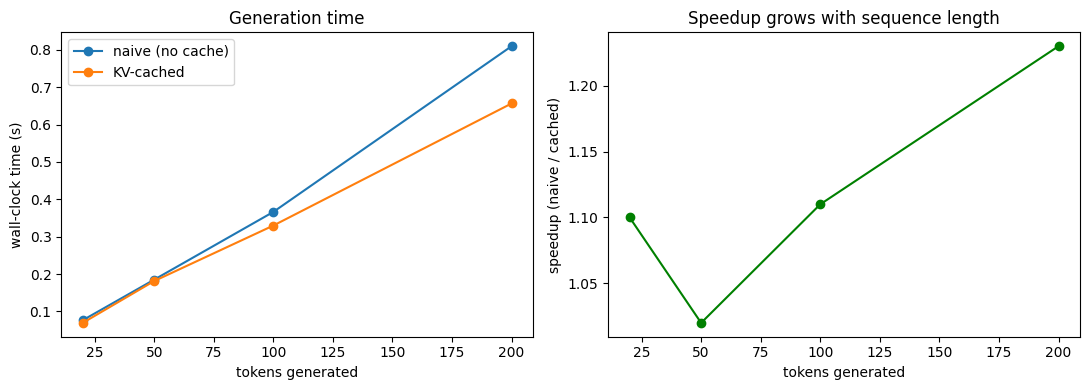

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(df['max_new_tokens'], df['naive_s'], marker='o', label='naive (no cache)')
ax[0].plot(df['max_new_tokens'], df['cached_s'], marker='o', label='KV-cached')
ax[0].set_xlabel('tokens generated')
ax[0].set_ylabel('wall-clock time (s)')
ax[0].set_title('Generation time')
ax[0].legend()

ax[1].plot(df['max_new_tokens'], df['speedup'], marker='o', color='green')
ax[1].set_xlabel('tokens generated')
ax[1].set_ylabel('speedup (naive / cached)')
ax[1].set_title('Speedup grows with sequence length')

plt.tight_layout()
plt.savefig('results/generation_speedup.png', dpi=150)
plt.show()

In [22]:
!cp results/generation_benchmark.csv results/generation_speedup.png {DRIVE_DIR}/results/
print('Backed up Phase 5 results to Drive.')

Backed up Phase 5 results to Drive.
